# TT-29 — TF-IDF: Tự động phân loại ticket hỗ trợ khách hàng

In [1]:
import time, itertools, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
SEED = 42
REPORTS = Path('../reports'); REPORTS.mkdir(parents=True, exist_ok=True)
MODELS = Path('../models');   MODELS.mkdir(parents=True, exist_ok=True)
REMOVE = ('headers', 'footers', 'quotes')   # cấu hình ĐÚNG, dùng từ Bước 2 trở đi

## Bước 1 — Chứng minh rò rỉ do headers / footers / quotes


,cau_hinh,accuracy_test
0,Không remove gì (rò rỉ nặng),0.8573
1,Chỉ bỏ headers,0.8218
2,Bỏ headers + footers,0.8096
3,Bỏ cả 3 (đúng chuẩn),0.6903


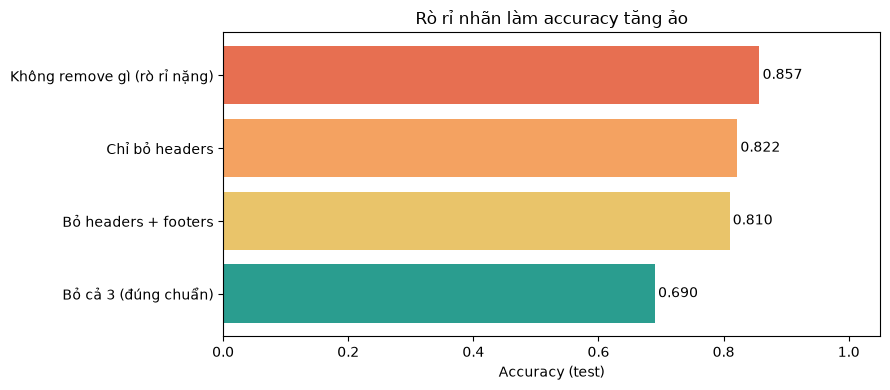

In [2]:
def chay(remove):
    tr = fetch_20newsgroups(subset='train', remove=remove)
    te = fetch_20newsgroups(subset='test',  remove=remove)
    pipe = make_pipeline(
        TfidfVectorizer(sublinear_tf=True, min_df=3, max_df=0.8),
        LinearSVC(random_state=SEED))
    pipe.fit(tr.data, tr.target)
    return accuracy_score(te.target, pipe.predict(te.data))

cau_hinh = {
    'Không remove gì (rò rỉ nặng)': (),
    'Chỉ bỏ headers':                ('headers',),
    'Bỏ headers + footers':          ('headers', 'footers'),
    'Bỏ cả 3 (đúng chuẩn)':          ('headers', 'footers', 'quotes'),
}
leak = pd.DataFrame({'cau_hinh': list(cau_hinh),
                     'accuracy_test': [chay(v) for v in cau_hinh.values()]})
display(leak.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(leak.cau_hinh[::-1], leak.accuracy_test[::-1], color=['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51'])
for i, v in enumerate(leak.accuracy_test[::-1]):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
ax.set_xlim(0, 1.05); ax.set_xlabel('Accuracy (test)')
ax.set_title('Rò rỉ nhãn làm accuracy tăng ảo')
plt.tight_layout(); plt.savefig(REPORTS / 'leakage_comparison.png', dpi=150); plt.show()

## Bước 2 — EDA (dữ liệu đã remove)

train: 11314 | test: 7532 | số lớp: 20
Văn bản rỗng: 300 | dưới 20 từ: 1186


,count,mean,std,min,25%,50%,75%,max
n_words,11314.0,185.8,524.0,0.0,40.0,83.0,167.0,11765.0


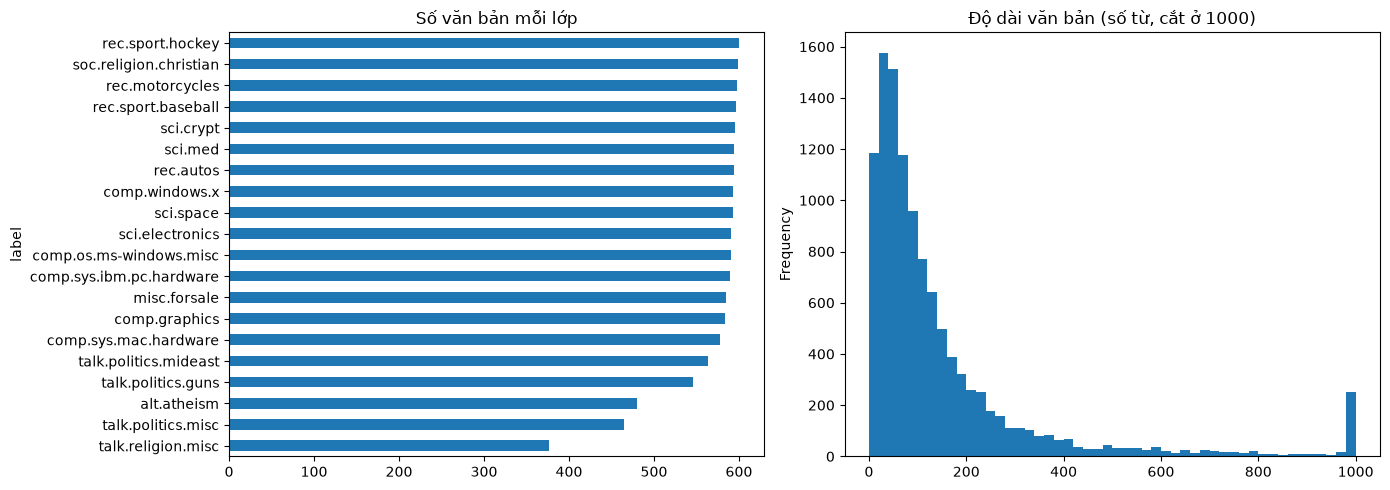

,ax,max,people,like,don,just,know,use,think,time,does,new,good,edu,way,make,god,used,ve,say
so_lan,62387,4585,4103,3964,3885,3752,3487,3179,3011,2968,2782,2609,2507,2436,2038,2030,1980,1880,1850,1849


In [3]:
train = fetch_20newsgroups(subset='train', remove=REMOVE)
test  = fetch_20newsgroups(subset='test',  remove=REMOVE)
names = train.target_names

df = pd.DataFrame({'text': train.data, 'y': train.target})
df['label']   = df.y.map(lambda i: names[i])
df['n_words'] = df.text.str.split().str.len()

print(f'train: {len(train.data)} | test: {len(test.data)} | số lớp: {len(names)}')
print(f'Văn bản rỗng: {(df.n_words == 0).sum()} | dưới 20 từ: {(df.n_words < 20).sum()}')
display(df.n_words.describe().round(1).to_frame().T)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df.label.value_counts().sort_values().plot.barh(ax=ax[0], title='Số văn bản mỗi lớp')
df.n_words.clip(upper=1000).plot.hist(bins=50, ax=ax[1], title='Độ dài văn bản (số từ, cắt ở 1000)')
plt.tight_layout(); plt.show()

cv = CountVectorizer(stop_words='english', min_df=5)
counts = np.asarray(cv.fit_transform(train.data).sum(axis=0)).ravel()
top20 = pd.Series(counts, index=cv.get_feature_names_out()).nlargest(20)
display(top20.to_frame('so_lan').T)

## Bước 3 — Baseline
- **Dummy** (luôn đoán lớp phổ biến nhất): mốc thấp nhất.
- **CountVectorizer + Naive Bayes**: baseline thực sự (TT-06).

In [4]:
dummy = DummyClassifier(strategy='most_frequent').fit(train.data, train.target)
nb_base = make_pipeline(CountVectorizer(min_df=3), MultinomialNB()).fit(train.data, train.target)

baseline = pd.DataFrame({
    'model': ['Dummy (lớp phổ biến nhất)', 'CountVectorizer + NaiveBayes'],
    'accuracy_test': [accuracy_score(test.target, dummy.predict(test.data)),
                      accuracy_score(test.target, nb_base.predict(test.data))]})
display(baseline.round(4))

,model,accuracy_test
0,Dummy (lớp phổ biến nhất),0.0530
1,CountVectorizer + NaiveBayes,0.6305


## Bước 4 — TF-IDF + LinearSVC
Cấu hình theo README: unigram + bigram, `min_df=3`, `max_df=0.8`, `sublinear_tf=True`, tối đa 50.000 đặc trưng.

In [5]:
tfidf_svc = make_pipeline(
    TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=3, max_df=0.8,
                    sublinear_tf=True, max_features=50000),
    LinearSVC(C=1.0, random_state=SEED))
tfidf_svc.fit(train.data, train.target)
acc_svc = accuracy_score(test.target, tfidf_svc.predict(test.data))
print(f'TF-IDF + LinearSVC — accuracy test: {acc_svc:.4f}   (mức tham chiếu ~0,69–0,73)')

TF-IDF + LinearSVC — accuracy test: 0.6818   (mức tham chiếu ~0,69–0,73)


## Bước 5 — Khảo sát tham số vectorizer
Khảo sát 3 tham số: `ngram_range`, `min_df`, `sublinear_tf`.
**Chọn tham số trên tập validation** (20% tách từ train), không dùng test để chọn → test chỉ để báo cáo cuối.

In [6]:
Xa, Xv, ya, yv = train_test_split(train.data, train.target, test_size=0.2,
                                  stratify=train.target, random_state=SEED)
rows = []
for ng, mdf, sub in itertools.product([(1, 1), (1, 2)], [1, 3, 5], [True, False]):
    vec = TfidfVectorizer(ngram_range=ng, min_df=mdf, max_df=0.8, sublinear_tf=sub)
    A = vec.fit_transform(Xa); V = vec.transform(Xv)
    clf = LinearSVC(random_state=SEED).fit(A, ya)
    rows.append(dict(ngram_range=ng, min_df=mdf, sublinear_tf=sub,
                     so_dac_trung=A.shape[1],
                     acc_val=accuracy_score(yv, clf.predict(V))))
grid = pd.DataFrame(rows).sort_values('acc_val', ascending=False).reset_index(drop=True)
display(grid.round(4))

,ngram_range,min_df,sublinear_tf,so_dac_trung,acc_val
0,"(1, 1)",1,True,90291,0.7684
1,"(1, 2)",1,False,798320,0.7645
2,"(1, 2)",1,True,798320,0.7636
3,"(1, 1)",1,False,90291,0.7627
4,"(1, 2)",3,True,99145,0.7521
5,"(1, 1)",3,True,23420,0.7517
6,"(1, 2)",3,False,99145,0.7464
7,"(1, 1)",3,False,23420,0.7455
8,"(1, 1)",5,True,15695,0.7441
9,"(1, 2)",5,True,51653,0.7437


## Bước 6 — So sánh 3 bộ phân loại trên cùng TF-IDF (NB · LogReg · LinearSVC)

In [7]:
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.8,
                      sublinear_tf=True, max_features=50000)
Xtr = vec.fit_transform(train.data)      # fit CHỈ trên train
Xte = vec.transform(test.data)

models = {
    'NaiveBayes': MultinomialNB(alpha=0.1),
    'LogReg':     LogisticRegression(C=10, max_iter=1000),
    'LinearSVC':  LinearSVC(C=1.0, random_state=SEED),
}
rows = []
for name, m in models.items():
    t0 = time.perf_counter(); m.fit(Xtr, train.target); t = time.perf_counter() - t0
    rows.append(dict(model=name, acc_test=accuracy_score(test.target, m.predict(Xte)),
                     thoi_gian_train_s=t))
cmp3 = pd.DataFrame(rows).sort_values('acc_test', ascending=False)
display(cmp3.round(4))

,model,acc_test,thoi_gian_train_s
2,LinearSVC,0.6818,1.6174
1,LogReg,0.6758,16.1234
0,NaiveBayes,0.6705,0.0482


## Bước 7 — Top 15 từ trọng số cao nhất mỗi lớp
Dùng `coef_` của LinearSVC (bản chưa calibrate). Hệ số lớn → từ đó đẩy mạnh về lớp này.
Ô dưới cũng tự quét các từ "đáng ngờ" (dấu vết header/email) để kiểm tra rò rỉ còn sót.

alt.atheism                atheism, atheists, religion, bobby, islamic, islam, deletion, motto, atheist, cruel, punishment, the motto, timmons, species, bake
comp.graphics              graphics, 3d, image, images, pov, animation, 68070, tiff, viewer, polygon, format, 3do, sphere, cview, vesa
comp.os.ms-windows.misc    windows, cica, file, win3, risc, ini, nt, w4wg, win, characters, mfc, microsoft, ms, drivers, norton
comp.sys.ibm.pc.hardware   vlb, ide, controller, bios, gateway, bus, pc, 486, os, irq, port, isa, scsi, cmos, adaptec
comp.sys.mac.hardware      mac, apple, powerbook, quadra, centris, duo, se, lc, adb, nubus, simms, c650, iisi, lciii, vram
comp.windows.x             motif, server, widget, xterm, x11r5, window, sun, widgets, mit, clients, xlib, x11, openwindows, hi, comp windows
misc.forsale               shipping, sell, offer, for sale, sale, forsale, wanted, condition, asking, new, postage, if interested, includes, su, summer
rec.autos                  car, cars, dealer,

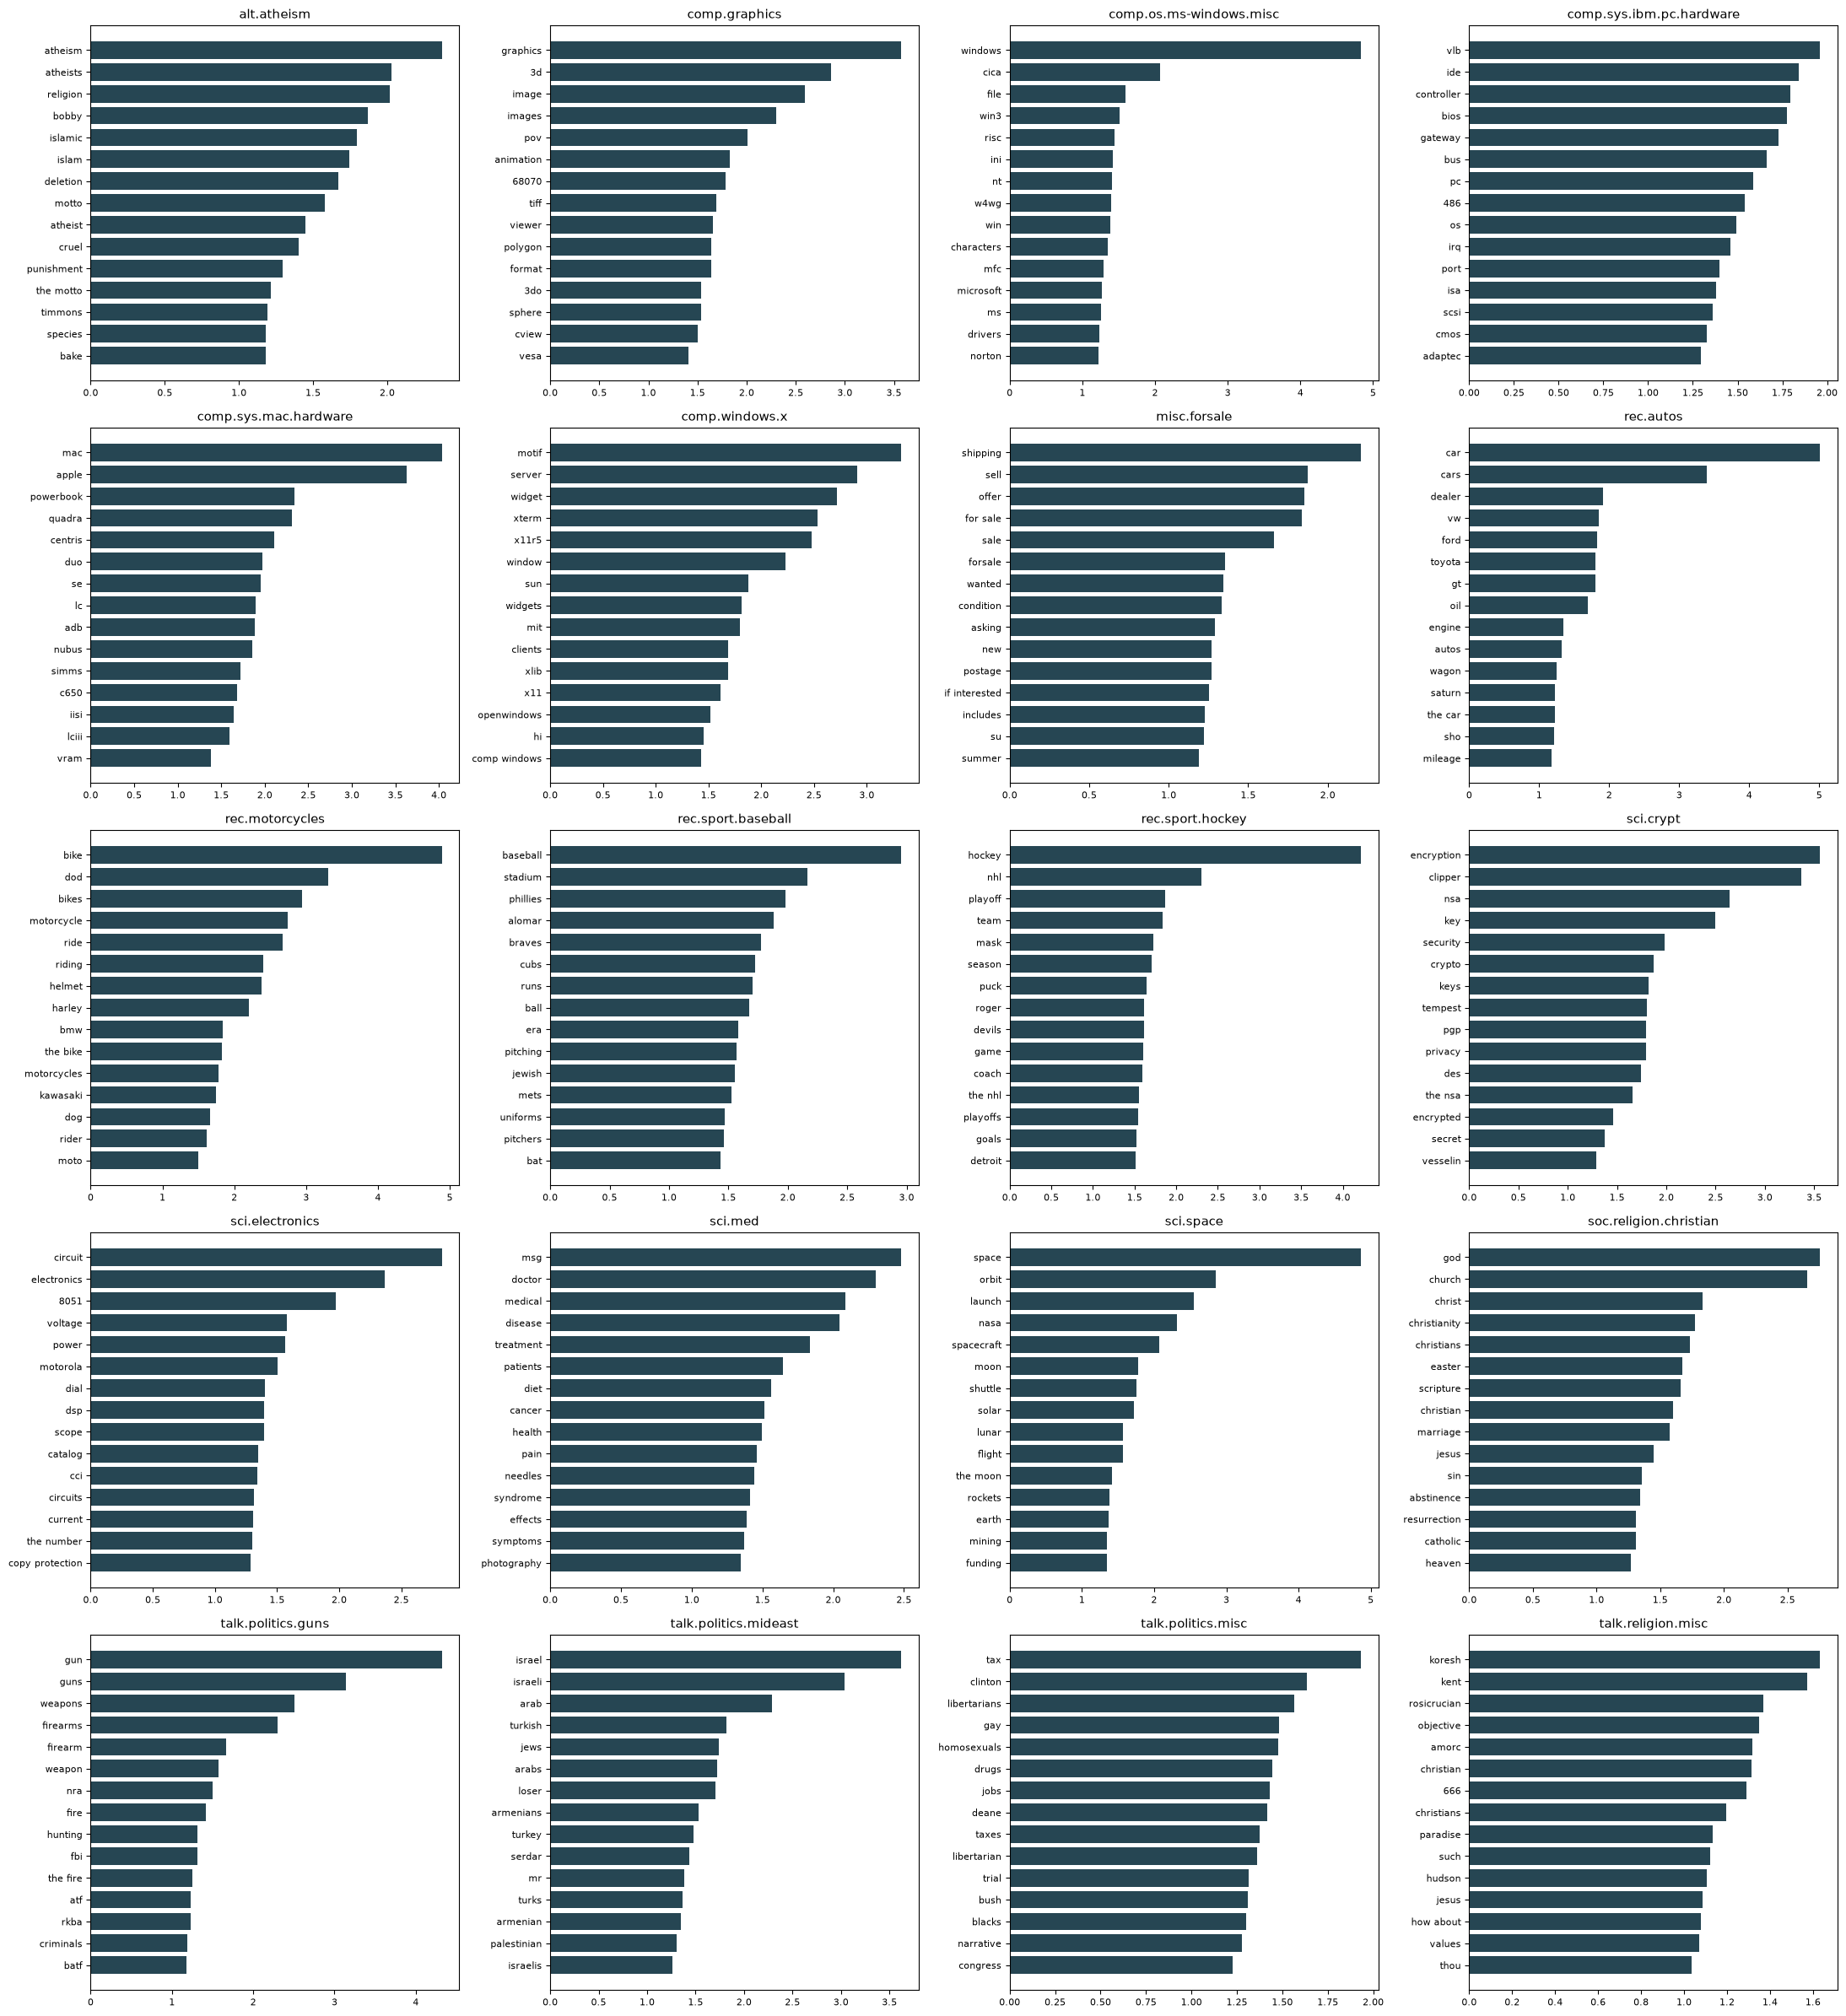

In [8]:
svc = models['LinearSVC']
feat = np.array(vec.get_feature_names_out())

top_words = {}
for i, c in enumerate(names):
    idx = np.argsort(svc.coef_[i])[-15:][::-1]
    top_words[c] = (feat[idx], svc.coef_[i][idx])

for c, (w, _) in top_words.items():
    print(f'{c:26s}', ', '.join(w))

# quét từ đáng ngờ
nghi_van = {'edu', 'com', 'writes', 'article', 'subject', 'lines', 'organization',
            'nntp', 'host', 'posting', 'reply', 'distribution'}
lot = {c: sorted(nghi_van & set(w)) for c, (w, _) in top_words.items() if nghi_van & set(w)}
print('\nTừ đáng ngờ lọt vào top 15:', lot if lot else 'không có')

fig, axes = plt.subplots(5, 4, figsize=(22, 24))
for ax, (c, (w, s)) in zip(axes.ravel(), top_words.items()):
    ax.barh(w[::-1], s[::-1], color='#264653'); ax.set_title(c, fontsize=11)
    ax.tick_params(labelsize=8)
plt.tight_layout(); plt.savefig(REPORTS / 'top_tu_moi_lop.png', dpi=120); plt.show()

## Bước 8 — Ma trận nhầm lẫn

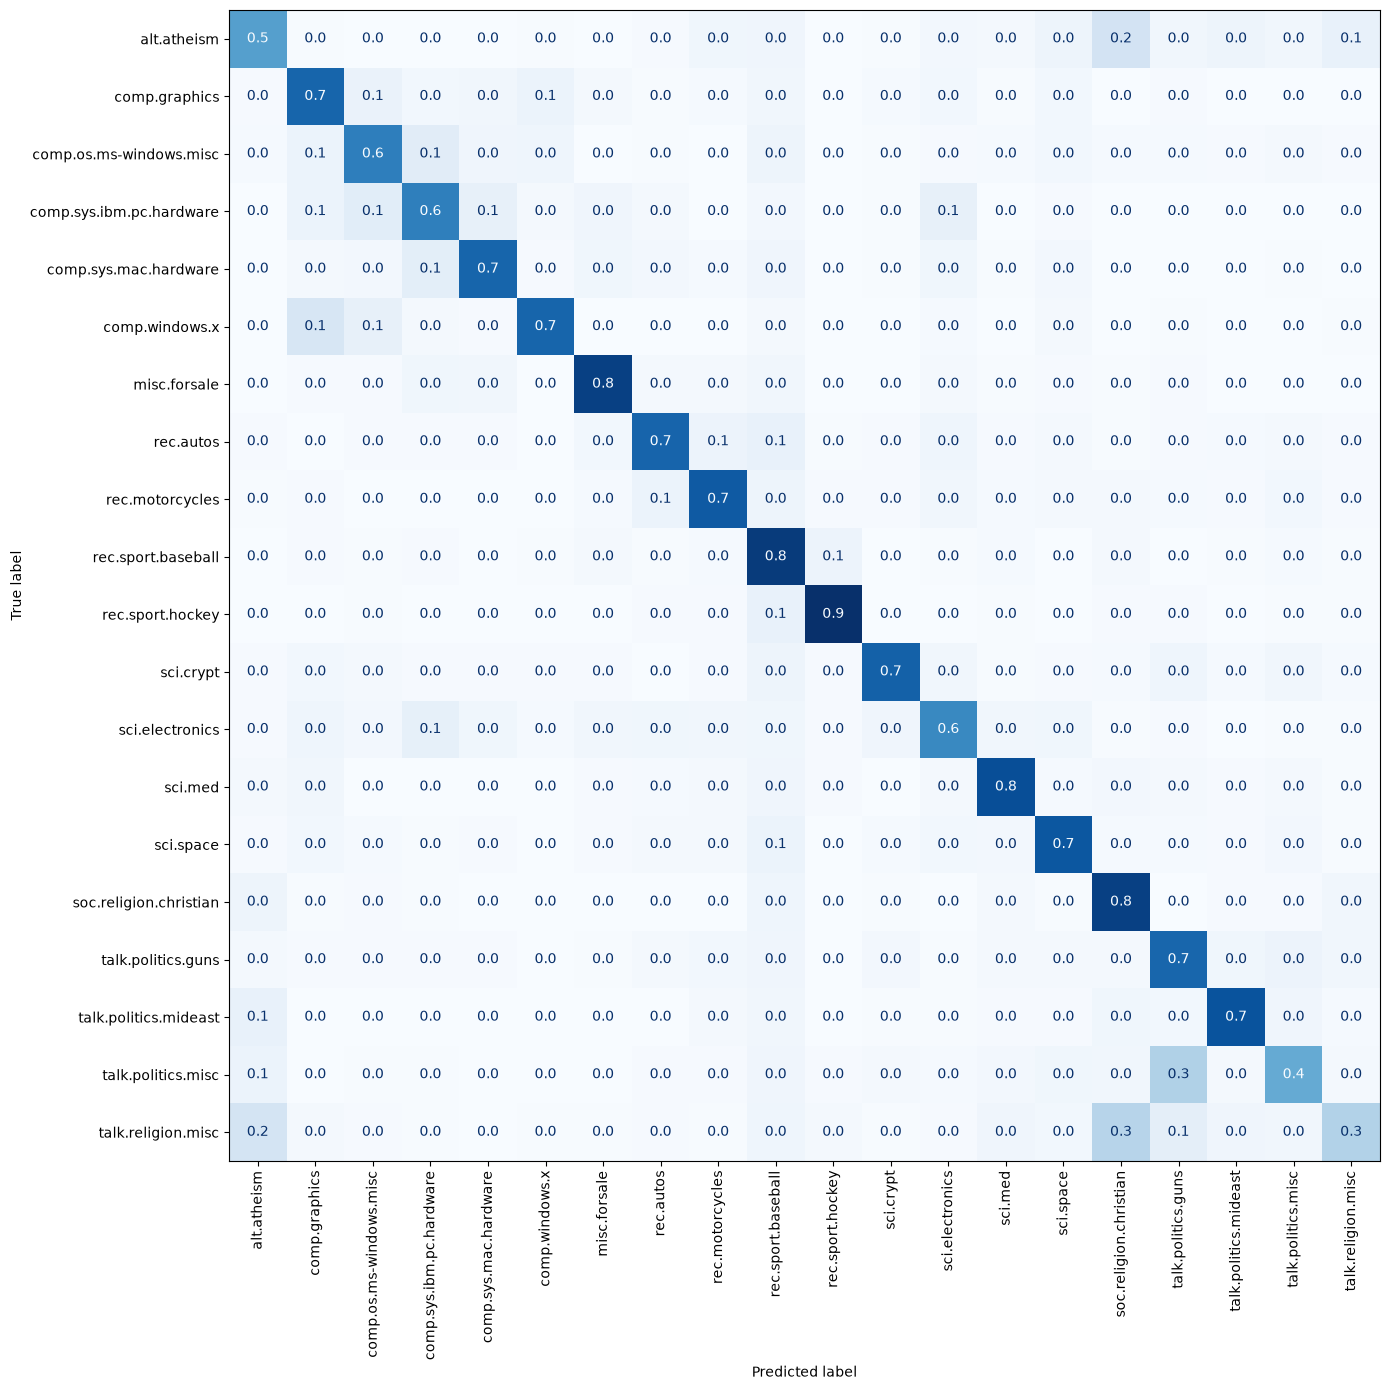

,that,bi_doan_thanh,so_van_ban
0,talk.politics.misc,talk.politics.guns,85
1,talk.religion.misc,soc.religion.christian,64
2,comp.windows.x,comp.graphics,54
3,alt.atheism,soc.religion.christian,50
4,talk.religion.misc,alt.atheism,38
5,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,38
6,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc,37
7,comp.sys.mac.hardware,comp.sys.ibm.pc.hardware,33
8,sci.electronics,comp.sys.ibm.pc.hardware,29
9,comp.sys.ibm.pc.hardware,sci.electronics,27


In [9]:
y_pred_svc = svc.predict(Xte)
fig, ax = plt.subplots(figsize=(14, 14))
ConfusionMatrixDisplay.from_predictions(
    test.target, y_pred_svc, display_labels=names, normalize='true',
    xticks_rotation=90, values_format='.1f', ax=ax, colorbar=False, cmap='Blues')
plt.tight_layout(); plt.savefig(REPORTS / 'confusion_matrix.png', dpi=120); plt.show()

cm = confusion_matrix(test.target, y_pred_svc)
np.fill_diagonal(cm, 0)
flat = np.argsort(cm.ravel())[::-1][:10]
pairs = pd.DataFrame([dict(that=names[i], bi_doan_thanh=names[j], so_van_ban=cm[i, j])
                      for i, j in zip(*np.unravel_index(flat, cm.shape))])
display(pairs)

## Bước 9 — Cơ chế ngưỡng tin cậy
`LinearSVC` không có `predict_proba` → bọc `CalibratedClassifierCV` để ra xác suất.
Quy tắc: `max(proba) >= ngưỡng` → tự động; ngược lại → chuyển người xử lý.
- Bảng **validation** để chọn ngưỡng.
- Bảng **test** để báo cáo (README yêu cầu ngưỡng 0,6).

VALIDATION


,nguong,pct_tu_dong,acc_phan_tu_dong,pct_can_nguoi
0,0.3,0.836,0.844,0.164
1,0.4,0.757,0.879,0.243
2,0.5,0.654,0.916,0.346
3,0.6,0.529,0.948,0.471
4,0.7,0.411,0.966,0.589
5,0.8,0.219,0.990,0.781
6,0.9,0.014,1.000,0.986


TEST


,nguong,pct_tu_dong,acc_phan_tu_dong,pct_can_nguoi
0,0.3,0.822,0.788,0.178
1,0.4,0.727,0.836,0.273
2,0.5,0.616,0.881,0.384
3,0.6,0.499,0.916,0.501
4,0.7,0.373,0.942,0.627
5,0.8,0.192,0.968,0.808
6,0.9,0.015,0.991,0.985


Accuracy toàn bộ (không ngưỡng): 0.6887


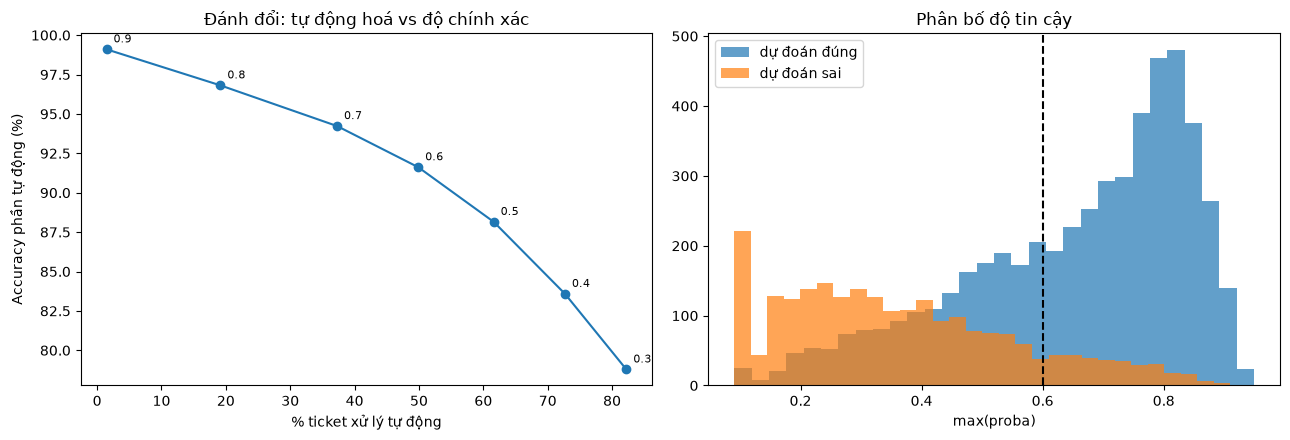

In [10]:
def bang_nguong(conf, pred, y, ths):
    rows = []
    for th in ths:
        m = conf >= th
        rows.append(dict(nguong=th,
                         pct_tu_dong=m.mean(),
                         acc_phan_tu_dong=(pred[m] == y[m]).mean() if m.any() else np.nan,
                         pct_can_nguoi=1 - m.mean()))
    return pd.DataFrame(rows)

THS = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
make_vec = lambda: TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.8,
                                   sublinear_tf=True, max_features=50000)

# (a) validation: fit trên Xa, đánh giá trên Xv
vec_v = make_vec().fit(Xa)
cal_v = CalibratedClassifierCV(LinearSVC(random_state=SEED), cv=3).fit(vec_v.transform(Xa), ya)
pv = cal_v.predict_proba(vec_v.transform(Xv))
bang_val = bang_nguong(pv.max(1), pv.argmax(1), yv, THS)
print('VALIDATION'); display(bang_val.round(3))

# (b) test: fit trên toàn bộ train
cal = CalibratedClassifierCV(LinearSVC(random_state=SEED), cv=3).fit(Xtr, train.target)
proba = cal.predict_proba(Xte)
conf, pred = proba.max(1), proba.argmax(1)
bang_test = bang_nguong(conf, pred, test.target, THS)
print('TEST'); display(bang_test.round(3))
print(f'Accuracy toàn bộ (không ngưỡng): {(pred == test.target).mean():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(bang_test.pct_tu_dong * 100, bang_test.acc_phan_tu_dong * 100, 'o-')
for _, r in bang_test.iterrows():
    ax[0].annotate(f'{r.nguong}', (r.pct_tu_dong * 100, r.acc_phan_tu_dong * 100),
                   textcoords='offset points', xytext=(5, 5), fontsize=8)
ax[0].set_xlabel('% ticket xử lý tự động'); ax[0].set_ylabel('Accuracy phần tự động (%)')
ax[0].set_title('Đánh đổi: tự động hoá vs độ chính xác')
ax[1].hist(conf[pred == test.target], bins=30, alpha=.7, label='dự đoán đúng')
ax[1].hist(conf[pred != test.target], bins=30, alpha=.7, label='dự đoán sai')
ax[1].axvline(0.6, color='k', ls='--'); ax[1].legend(); ax[1].set_xlabel('max(proba)')
ax[1].set_title('Phân bố độ tin cậy')
plt.tight_layout(); plt.savefig(REPORTS / 'nguong_tin_cay.png', dpi=150); plt.show()

## Bước 10 — Đo thời gian
Train toàn pipeline (TF-IDF + calibrated LinearSVC) và đo thời gian dự đoán **1 ticket** (trung bình 300 lần, sau khi khởi động). Yêu cầu < 5 ms.

In [11]:
final = make_pipeline(
    TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=3, max_df=0.8,
                    sublinear_tf=True, max_features=50000),
    CalibratedClassifierCV(LinearSVC(C=1.0, random_state=SEED), cv=3))

t0 = time.perf_counter(); final.fit(train.data, train.target)
t_train = time.perf_counter() - t0

doc = [test.data[0]]
final.predict_proba(doc)                          # khởi động
ts = []
for _ in range(300):
    t0 = time.perf_counter(); final.predict_proba(doc); ts.append((time.perf_counter() - t0) * 1000)

print(f'Train toàn bộ: {t_train:.1f} s')
print(f'Dự đoán 1 văn bản: trung bình {np.mean(ts):.2f} ms | p95 {np.percentile(ts, 95):.2f} ms')
print('ĐẠT < 5 ms' if np.mean(ts) < 5 else 'CHƯA ĐẠT — thử giảm max_features hoặc bỏ bigram')

Train toàn bộ: 8.1 s
Dự đoán 1 văn bản: trung bình 4.01 ms | p95 4.98 ms
ĐẠT < 5 ms


## Bước 11 — Phân tích 10 ca sai

In [12]:
n_words = np.array([len(t.split()) for t in test.data])
dung = pred == test.target
print(pd.DataFrame({
    'nhom': ['dự đoán đúng', 'dự đoán sai'],
    'conf_trung_binh': [conf[dung].mean(), conf[~dung].mean()],
    'so_tu_trung_vi':  [np.median(n_words[dung]), np.median(n_words[~dung])]}).round(3))

rng = np.random.default_rng(SEED)
sai = np.where(~dung)[0]
for i in rng.choice(sai, 10, replace=False):
    print(f'#{i}  THẬT: {names[test.target[i]]}  →  ĐOÁN: {names[pred[i]]}  (conf={conf[i]:.2f}, {n_words[i]} từ)')
    print('   ', test.data[i][:300].replace('\n', ' '), '\n')

           nhom  conf_trung_binh  so_tu_trung_vi
0  dự đoán đúng            0.656            99.0
1   dự đoán sai            0.363            50.0
#624  THẬT: misc.forsale  →  ĐOÁN: rec.autos  (conf=0.09, 0 từ)
      

#5747  THẬT: misc.forsale  →  ĐOÁN: rec.autos  (conf=0.09, 0 từ)
      

#647  THẬT: misc.forsale  →  ĐOÁN: talk.politics.guns  (conf=0.23, 9 từ)
     	Again, tell us about it Ken!  -=- Andy -=-  

#4871  THẬT: alt.atheism  →  ĐOÁN: talk.religion.misc  (conf=0.43, 220 từ)
    Here's a suggestion for the logical argument FAQ.  I don't think it's covered, though the fallacy probably has a better name than the one I used:  How about it, mathew?  INCONSISTENCY AND COUNTEREXAMPLE  This occurs when one party points out that some source of information takes stand A, which is in 

#3261  THẬT: comp.windows.x  →  ĐOÁN: rec.autos  (conf=0.09, 0 từ)
      

#3228  THẬT: talk.religion.misc  →  ĐOÁN: talk.politics.misc  (conf=0.57, 111 từ)
    #I find myself unable to put these two s

## Bước 12 — Lưu model & tổng kết

In [13]:
joblib.dump(final, MODELS / 'tfidf_pipeline.joblib')
print('Đã lưu:', (MODELS / 'tfidf_pipeline.joblib').resolve())

tong_ket = pd.DataFrame([
    ('Dummy',                       baseline.accuracy_test[0]),
    ('CountVectorizer + NB',        baseline.accuracy_test[1]),
    ('TF-IDF + LinearSVC',          acc_svc),
    ('TF-IDF + LinearSVC (calib.)', (pred == test.target).mean()),
], columns=['model', 'accuracy_test'])
display(tong_ket.round(4))

Đã lưu: D:\TT_ML\TT-29-TF-IDF_Linh\models\tfidf_pipeline.joblib


,model,accuracy_test
0,Dummy,0.0530
1,CountVectorizer + NB,0.6305
2,TF-IDF + LinearSVC,0.6818
3,TF-IDF + LinearSVC (calib.),0.6887
